In [1]:
import xgboost as xgb 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Regression Basic
- Outcome is real-valued

# Metric to find out the performance of regression models
- Root mean squared error (RMSE)
- Mean Absolute error (MAE)

# How is RMSE computed
- Tasking the difference between the actual and the predicted values
- Squaring those differences computing the means abd taking that value's square root 
- This allows us to treat negative and positive differences equally but tends to punish larger differences


# How is MAE computed 
- simply sum the absolute differences between predicted and actual values across all of the sample we build our model on
- Although MAE isnt affected by some large differences as much as RMSE it lacks some nice mathematical properties that make it less frequently used as an evaluation metric


# Objective (loss) functions and base learners

### Objective loss functions and why we use them
- Quanitifies how far off a prediction is from the actual result
- Measures the difference between estimated and true values for some collection of data
- Goal : Find the model that yields the minimum value of the loss function

### Common loss functions and XGBoost 
- loss function names in xgboost
    - reg:squarederror - use for regression problems
    - reg:logistic - use for classification problems when you want just descision not probabiliy
    - binary:logistic - use when you want probability rather than just a decision

### Base learners and why we need them
- XGBoost involves creating a meta-model that is composed of many individual models that combine to give a final prediction
- individual models = base learners
- Want base learneers that when combined create final prediction that is non-linear
- each base learner should be good at distinguishing or predicting different parts of the dataset
- Two kind of base learners tree and Linear



# Tree as base learners example 

In [2]:
df = pd.read_csv('../resources/housing.csv')

In [3]:
X , y = df.iloc[:,:-1] , df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

xg_reg = xgb.XGBRegressor(objective='reg:squarederror',n_estimators=10,seed=123)

xg_reg.fit(X_train,y_train)

preds = xg_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test,preds))

print(rmse)

31292.976336551947


# Linear base learner

In [4]:
X , y = df.iloc[:,:-1] , df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

DM_train = xgb.DMatrix(data=X_train,label=y_train)
DM_test = xgb.DMatrix(data=X_test,label=y_test)

params = {'booster':'gblinear','objective':'reg:squarederror'}

xg_reg = xgb.train(params=params,dtrain=DM_train,num_boost_round=10)


preds = xg_reg.predict(DM_test)

rmse = np.sqrt(mean_squared_error(y_test,preds))

print(rmse)


42427.91533884266


# Regularization and base learners in XGBoost

- Regularization is a control on model complexity by penalizing the model
- loss functions are used to find models that are both accurate and as simple as they can possibly be .
- Want models that are both accurate and as simple as possible
- **Regularization parameters in XGBoost**
    - **gamma** - minimum loss reduction allowed for a split to occur
    - **alpha** - l1 regularization on leaf weights , larger valyes mean more regularization
    - **lamba** - l2 regularization on leaf weights .

# L1 regularization in XGBoost example

In [5]:
X , y = df.iloc[:,:-1] , df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

df_DMatrix = xgb.DMatrix(data=X,label=y)

params = {'max_depth':4 ,'objective':'reg:squarederror'}

xg_reg = xgb.train(params=params,dtrain=df_DMatrix,num_boost_round=10)



l1_params = [1,10,100]
rmse_l1 = []

for reg in l1_params:
    params['alpha'] = reg
    cv_results = xgb.cv(dtrain=df_DMatrix,params=params,nfold=4,num_boost_round=10,metrics='rmse',as_pandas=True,seed=123)
    rmse_l1.append(cv_results['test-rmse-mean'].tail(1).values[0])

print('Best rmse as a function of l1:')
print(pd.DataFrame(list(zip(l1_params,rmse_l1)),columns=['l1','rmse']))


Best rmse as a function of l1:
    l1          rmse
0    1  33494.293752
1   10  33494.266946
2  100  33542.725207


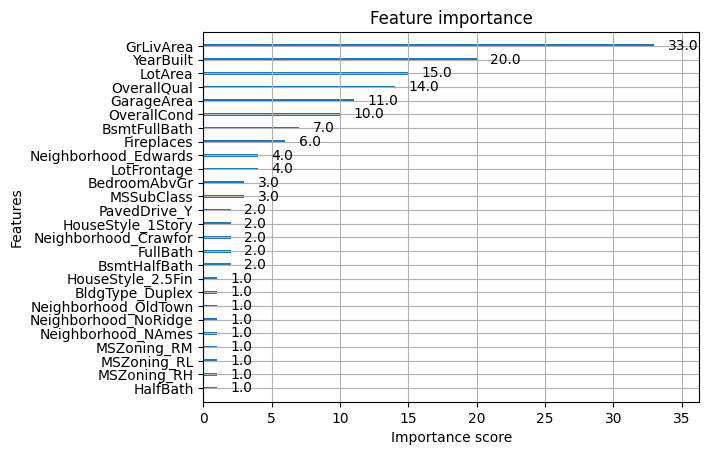

In [6]:
xgb.plot_importance(xg_reg)
plt.show()

# L2 Regulatization

In [8]:
# Create the DMatrix: housing_dmatrix
housing_dmatrix = xgb.DMatrix(data=X, label=y)

reg_params = [1, 10, 100]

# Create the initial parameter dictionary for varying l2 strength: params
params = {"objective":"reg:squarederror","max_depth":4}

# Create an empty list for storing rmses as a function of l2 complexity
rmses_l2 = []

# Iterate over reg_params
for reg in reg_params:

    # Update l2 strength
    params["lambda"] = reg
    
    # Pass this updated param dictionary into cv
    cv_results_rmse = xgb.cv(dtrain=housing_dmatrix,params=params, nfold=4, num_boost_round=10, metrics="rmse", as_pandas=True, seed=123)
    
    # Append best rmse (final round) to rmses_l2
    rmses_l2.append(cv_results_rmse['test-rmse-mean'].tail(1).values[0])

# Look at best rmse per l2 param
print("Best rmse as a function of l2:")
print(pd.DataFrame(list(zip(reg_params, rmses_l2)), columns=["l2", "rmse"]))

Best rmse as a function of l2:
    l2          rmse
0    1  33494.297305
1   10  35447.853745
2  100  40767.593789


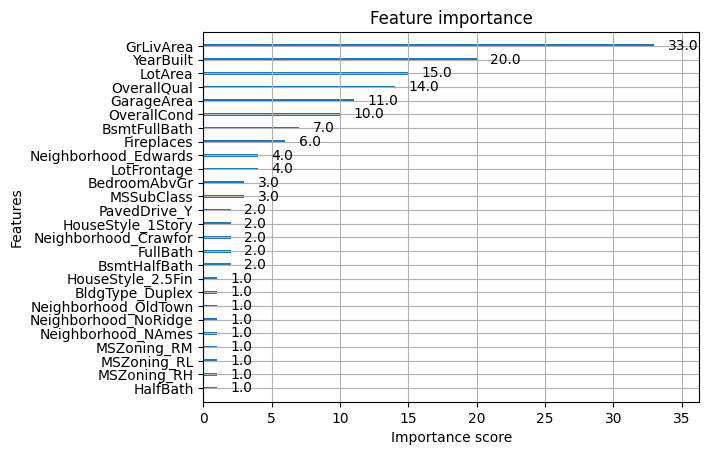

In [ ]:
xgb.plot_importance(xg_reg)
plt.show()

# Base learners in XGBoost
- Linear Base learner :
    - Sum of linear terms
    - Boosted model is weighted sum of linear models
    - rarely used
- Tree base Learner
    - Descision tree
    - Boosted model is weighted sum of descision trees
    - Almost exlusively used in XGboost

# Creating Data frames from multiple equal-length lists
- pd.DataFrame(list(zip(list1,list2)),columns=['list1','list2']) 
- zip creates a **generator** need to be completely instantiated before they can be used in Dataframe objects
- list() instatiates the full generator and passing that into the DataFrame converts the whole expression

# Overview of XGBoost's hyperparameters

## For tree based tunable parameters
- **learning rate** : it affects how quickly the model fits the residual error using addition base learners . A low learning rate will require more boosting rounds to achieve the same reduction in residual error as an XGBoost model with a high learning rate 
- **Gamma** : min loss reduction to create new tree split
- **lambda** : L2 reg on leaf weights 
- **alpha** : L1 reg on leaf weights
- **max_depth** : max depth per tree must be a positive integer and affects how deeply each tree is allowed to grow during any given boosting round
- **subsample** : Must be a value between 0 and 1 and is the fraction of the total training set that can be used for any given boosting round. if the value is low then the fraction of your training data used would per boosting round would be low and may run into underfitting problems a value that is very high can lead to overfitting as well.
- **colsample_bytree** : is the fraction of features that you can select from during any given boosting round and must also be a value between 0 and 1. A large valye means that almost all features can be used to build a tree during a given boosting round . whereas a samll value means that the fraction of features that can be selected from is very small . in general smaller colsample_bytree values can be thought of as providing additional regularization to the model , where as using all columns may in certain cases overfit a trained model

## for linear base models
- **lambda** : L2 reg on weights 
- **alpha** : L1 reg on weights
- **lambda_bias** : l2 reg term on bias
- You can also tune the number of estimators used for both model types


# Review of grid search and random search

## Grid Search 
- Search exhaistively over a given set of hyperparamters , once per set of hyperparameters
- Number of models = number of distinct values per hperparameter multiplied across each hyperparameter
- pick final model hyperparameter values that give best cross-validated evaluation metric value


In [9]:
from sklearn.model_selection import GridSearchCV

X , y = df.iloc[:,:-1] , df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

df_DMatrix = xgb.DMatrix(data=X,label=y)

gbm_param_grid = {'learning_rate' : [0.01,0.1,0.5,0.9],
                  'n_estimators':[200],
                  'subsample':[0.3,0.5,0.9]}

gbm = xgb.XGBRegressor()
grid_mse = GridSearchCV(estimator=gbm,param_grid=gbm_param_grid,scoring='neg_mean_squared_error',cv=4,n_jobs=-1)
grid_mse.fit(X,y)
print('Best params found : ',grid_mse.best_params_)
print('Lowest RMSE found: ',np.sqrt(np.abs(grid_mse.best_score_)))

Best params found :  {'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.5}
Lowest RMSE found:  28518.027421264607


## Ramdon search : review
- Create a possibly infinite range of hyperparameter values per hyperparameter that you would like to search over
- Set the number of iterations you would like for random search to continue 
- During each iteration randomly draw a valye in the range of specified values for each hyperparameter searched over and train/evaluate a model with those hyperparameters
- After you've reached the maximum number of iterations , select the hyperparamter configuration with the best evaluated score

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

X , y = df.iloc[:,:-1] , df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

df_DMatrix = xgb.DMatrix(data=X,label=y)

gbm_param_grid = {'learning_rate' : np.arange(0.05,1.05,.05),
                  'n_estimators':[200],
                  'subsample': np.arange(0.05,1.05,.05)}

gbm = xgb.XGBRegressor()
randomised_mse = RandomizedSearchCV(estimator=gbm,param_distributions=gbm_param_grid,scoring='neg_mean_squared_error',cv=4,n_iter=25)
randomised_mse.fit(X,y)

print('Best params found : ',randomised_mse.best_params_)
print('Lowest RMSE found: ',np.sqrt(np.abs(randomised_mse.best_score_)))

Best params found :  {'subsample': np.float64(0.5), 'n_estimators': 200, 'learning_rate': np.float64(0.05)}
Lowest RMSE found:  28219.15434594028


# Grid Search and Random Search limitations
- Grid Search 
    - Numbers of models you must build with every additional new parameter grows very quickly
- Random Search 
    - Parameter space to explore can be massive 
    - Randomly jumping throughout the best space looking for a 'best' result becomes a waiting game

# Excercise